# An initial training pipeline

In [1]:
%load_ext dotenv
%dotenv 
import os
import sys
sys.path.append(os.getenv('SRC_DIR'))
import dask.dataframe as dd
import pandas as pd
import numpy as np

from glob import glob
ft_dir = os.getenv("FEATURES_DATA")
ft_glob = glob(ft_dir+'/*.parquet')
df = dd.read_parquet(ft_glob).compute().reset_index().dropna()


c:\Users\Suha\miniconda3\envs\dsi_suha\lib\site-packages\dask\dataframe\__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
cat_file = os.path.join(
    os.getenv("PRICE_CSV_DATA"), 
    'symbols_valid_meta.csv'
)
cat_df = (pd.read_csv(cat_file)
          .rename(columns = {'Symbol': 'ticker'})[['ticker', 'Listing Exchange', 'Market Category']]
          )
df = df.merge(cat_df, on = 'ticker', how = 'left')

## Preprocessing

+ Previously, we produced a features data set.
+ Most times, one or more [preprocessing steps](https://scikit-learn.org/stable/modules/preprocessing.html#) steps will be applied to data.
+ The most practical way to apply them is by arranging them in `Pipeline` objects, wchich are sequential transformations applied to data. 
+ It is convenient for us to label these transformations and there is a standard way of doing so.


## Transformations

+ Transformations are classes that implement `fit` and `transform` methods.

### StandardScaler

+ For example, transform a numerical variable by standardizing it.
- Standardization is removing the mean value of the feature and scale it by dividing non-constant features by their standard deviation.

$$
z = \frac{x-\mu}{\sigma}
$$


+  Using [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), one can do the following:

In [3]:
df.columns

Index(['ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'source', 'Year', 'Close_lag_1', 'Listing Exchange', 'Market Category'],
      dtype='object')

In [4]:
df = (df.assign(
        returns = lambda x: x['Close']/x['Close_lag_1'] - 1, 
        positive_return = lambda x: 1.0*(x['returns'] > 0),
        hi_lo = lambda x: x['High'] - x['Low'],
        op_cl = lambda x: x['Close'] - x['Open']
    ).groupby(['ticker'], group_keys=False).apply(
        lambda x: x.assign(target = x['positive_return'].shift(-1))
    )
    .reset_index(drop=True)
    .dropna(subset = ['target'])
    )
df

C:\Users\Suha\AppData\Local\Temp\ipykernel_9448\619560177.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = (df.assign(


,ticker,Date,Open,High,Low,Close,Adj Close,Volume,source,Year,Close_lag_1,Listing Exchange,Market Category,returns,positive_return,hi_lo,op_cl,target
0,AACG,2019-03-12,1.08,1.09,1.05,1.05,1.05,20200.0,AACG.csv,2019,1.08,Q,G,-0.027778,0.0,0.04,-0.03,1.0
1,AACG,2019-03-13,1.06,1.08,1.04,1.07,1.07,23100.0,AACG.csv,2019,1.05,Q,G,0.019048,1.0,0.04,0.01,1.0
2,AACG,2019-03-14,1.06,1.11,1.06,1.08,1.08,29900.0,AACG.csv,2019,1.07,Q,G,0.009346,1.0,0.05,0.02,0.0
3,AACG,2019-03-15,1.06,1.08,1.04,1.04,1.04,30900.0,AACG.csv,2019,1.08,Q,G,-0.037037,0.0,0.04,-0.02,1.0
4,AACG,2019-03-18,1.07,1.07,1.03,1.07,1.07,48800.0,AACG.csv,2019,1.04,Q,G,0.028846,1.0,0.04,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359761,ZIXI,2003-06-25,4.15,4.18,3.99,4.04,4.04,112100.0,ZIXI.csv,2003,4.25,Q,Q,-0.049412,0.0,0.19,-0.11,0.0
359762,ZIXI,2003-06-26,4.04,4.19,3.86,4.00,4.00,515300.0,ZIXI.csv,2003,4.04,Q,Q,-0.009901,0.0,0.33,-0.04,0.0
359763,ZIXI,2003-06-27,4.00,4.05,3.79,3.85,3.85,162400.0,ZIXI.csv,2003,4.00,Q,Q,-0.037500,0.0,0.26,-0.15,0.0
359764,ZIXI,2003-06-30,3.84,4.00,3.72,3.77,3.77,119900.0,ZIXI.csv,2003,3.85,Q,Q,-0.020779,0.0,0.28,-0.07,1.0


In [6]:
# Create a StandardScaler object

from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()


# Fit the StandardScaler object with the returns data
std_scaler.fit(df.returns.values.reshape(-1, 1))

StandardScaler()

In [8]:
# Transform the returns data using the fitted scaler

returns = df.returns.values.reshape(-1, 1)
scaled_returns_np = std_scaler.transform(returns)
scaled_returns = pd.DataFrame(scaled_returns_np, columns=['returns'])
scaled_returns.describe()

,returns
count,3.596770e+05
mean,-2.568153e-19
std,1.000001e+00
min,-8.841761e-01
25%,-1.200979e-02
50%,-3.273667e-03
75%,5.599320e-03
max,5.082856e+02


In [9]:
df.returns.describe()

count    359677.000000
mean          0.003697
std           1.129281
min          -0.994785
25%          -0.009866
50%           0.000000
75%           0.010020
max         574.000021
Name: returns, dtype: float64

###  OneHotEncoder

+ Categorical features can be encoded as numerical values using `OneHotEncoder`.

<Axes: xlabel='Listing Exchange'>

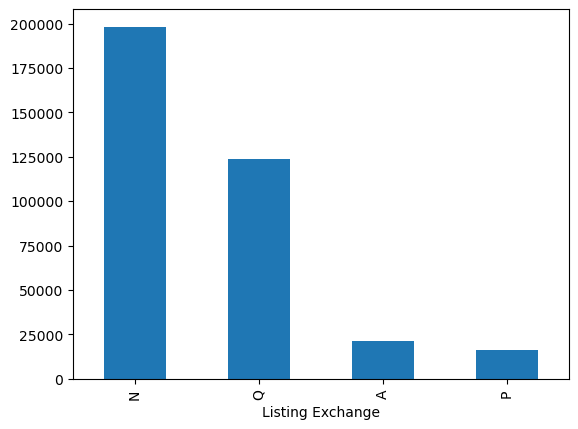

In [10]:
df['Listing Exchange'].value_counts().plot(kind = 'bar')

+ Use [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) to encode a categorical variable as numerical.
+ Important parameters:

    - `categories` allows you to specify the categories to work with.
    - `drop`: we can drop the `'first'` value (dummy encoding) or `'if_binary'`, a convenience setting for binary values.
    - `handle_unknown` allows three options, `'error'`, `'ignore'`, and `'infrequent_if_exist'`, depending on what we want to do with new values.

In [11]:
from sklearn.preprocessing import OneHotEncoder
onehot = OneHotEncoder()
onehot.fit(df[['Listing Exchange']])

OneHotEncoder()

In [12]:
listing_enc = onehot.transform(df[['Listing Exchange']])
listing_enc.toarray()

array([[0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]])

In [13]:
listing_enc

<359677x4 sparse matrix of type '<class 'numpy.float64'>'
	with 359677 stored elements in Compressed Sparse Row format>

# Pipelines

+ It is impractical and costly to manipulate data "by hand". 
+ To manage data preprocessing steps within the cross-validation process use `Pipeline` objects.
+ A [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) object allows us to sequentially apply transformation steps and, if required, a predictor.
+ `Pipeline` objects compose transforms, i.e., classes that implement `transform` and `fit` methods.
+ The purpose of `Pipeline` objects is to ensemble transforms and predictors to be used in cross-validation.
+ A `Pipeline` is defined by a list of tuples.
+ Each tuple is composed of `("name", <ColumnTransformer>)`, the name of the step and the `<ColumnTransformer>` function of our chosing.

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, cohen_kappa_score, f1_score


In [15]:
pipe1 = Pipeline(
    [
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ('knn', DecisionTreeClassifier(criterion = 'entropy', max_depth=3))

    ]
)
pipe1

Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore')),
                ('knn',
                 DecisionTreeClassifier(criterion='entropy', max_depth=3))])

In [16]:
X0 = df[['Listing Exchange', 'Market Category']]
Y0 = df['target']
X0_train, X0_test, Y0_train, Y0_test = train_test_split(X0, Y0, test_size=0.2, random_state=42)

pipe1.fit(X0_train, Y0_train)

Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore')),
                ('knn',
                 DecisionTreeClassifier(criterion='entropy', max_depth=3))])

In [17]:
Y_pred_train = pipe1.predict(X0_train)
Y_pred_test = pipe1.predict(X0_test)

In [18]:
Y_poba_train = pipe1.predict_proba(X0_train)
Y_proba_test = pipe1.predict_proba(X0_test)

In [20]:
Y_pred_train
Y_poba_train

array([[0.53424914, 0.46575086],
       [0.53424914, 0.46575086],
       [0.53424914, 0.46575086],
       ...,
       [0.53424914, 0.46575086],
       [0.53424914, 0.46575086],
       [0.53424914, 0.46575086]])

In [21]:
res = {
    'accuracy_score_train': accuracy_score(Y0_train, Y_pred_train),
    'accuracy_score_test': accuracy_score(Y0_test, Y_pred_test),
    'cohen_kappa_train': cohen_kappa_score(Y0_train, Y_pred_train),
    'cohen_kappa_test': cohen_kappa_score(Y0_test, Y_pred_test),
    'log_loss_train': log_loss(Y0_train, Y_poba_train),
    'log_loss_test': log_loss(Y0_test, Y_proba_test),
    'f1_score_train': f1_score(Y0_train, Y_pred_train),
    'f1_score_test': f1_score(Y0_test, Y_pred_test)
}
res

{'accuracy_score_train': 0.544277666373579,
 'accuracy_score_test': 0.5446508007117438,
 'cohen_kappa_train': np.float64(0.0),
 'cohen_kappa_test': np.float64(0.0),
 'log_loss_train': 0.6883465126627176,
 'log_loss_test': 0.6882660884735489,
 'f1_score_train': 0.0,
 'f1_score_test': 0.0}

+ The model does not show great performance, but the pipeline shows results. 
+ Below, we expand the pipeline to include more variables, and further we will work with more robust model selection pipelines.

## ColumnTransformer

+ Use [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) to apply transformers to specific columns of a DataFrame.
+ In this case, we will scale numeric variables and apply one-hot encoding to categorical columns.

In [23]:
from sklearn.compose import ColumnTransformer

In [24]:
transformer = ColumnTransformer(
    transformers=[
        ('numeric_transfomer', StandardScaler(), ['returns', 'Volume', 'op_cl', 'hi_lo'] ),
        ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist'), ['Listing Exchange', 'Market Category']), 
    ], remainder='drop'
)

pipe = Pipeline(
    [
        ('preproc', transformer), 
        ('decisiontree', DecisionTreeClassifier(criterion = 'entropy', max_depth=3))
    ]
)

In [25]:
pipe

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('numeric_transfomer',
                                                  StandardScaler(),
                                                  ['returns', 'Volume', 'op_cl',
                                                   'hi_lo']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                  ['Listing Exchange',
                                                   'Market Category'])])),
                ('decisiontree',
                 DecisionTreeClassifier(criterion='entropy', max_depth=3))])

# Model Selection

The model selection process is an iterative process in which :

+ Select schema and load data.
+ Define a pipeline and its (hyper) parameters.

    - Use ColumnTransformers to transform numeric and cateogrical variables.
    - Hyperparameters can be defined independently of code. 

+ Implement a splitting strategy. 

    - Use [cross_validate]() to select several metrics and operational details.

+ Measure performance.

    - [Select metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics)

+ Repeat

## Training, Validation, Testing Split

+ The first spliting strategy is to use a training, validation, and test set.
+ Training set will be used to fit the model.
+ Validation set is used to evaluate hyperparameter choice.
+ Testing set is used to evaluate performance on data the model has not yet seen.
+ In this case we want to compare two models: 

    - Decision Tree with 3 minumum samples per leaf.
    - Decision Tree with 10 minimum samples per leaf.

![](./images/03b_train_validate_test.png)

## Setting parameters in pipeline steps

+ One can obtain the parameters of a pipeline with `pipe.get_params()`.
+ We can set any parameter of a pipeline with `pipe.set_parames(**kwargs)`. 
+ The input `**kwargs` is a dictionary of the params to be modified. Params of the steps are labeled with the name of the step followed by `__` and the name of the parameter.

+ There are a few steps that we will repeat: 

    - Fit the candidate model on training data.
    - Predict on training and test data.
    - Compute training and test performance metrics.
    - Return.

+ We encapsulate this procedure in a function. 

In [26]:
def evaluate_model(clf, X_train, Y_train, X_test, Y_test):
    clf.fit(X_train, Y_train)
    Y_pred_train = clf.predict(X_train)
    Y_pred_test = clf.predict(X_test)
    Y_proba_train = clf.predict_proba(X_train)
    Y_proba_test = clf.predict_proba(X_test)
    performance_metrics = {
        'log_loss_train': log_loss(Y_train, Y_proba_train),
        'log_loss_test': log_loss(Y_test, Y_proba_test),
        'cohen_kappa_train': cohen_kappa_score(Y_train, Y_pred_train),
        'cohen_kappa_test': cohen_kappa_score(Y_test, Y_pred_test),
        'f1_score_train': f1_score(Y_train, Y_pred_train),
        'f1_score_test': f1_score(Y_test, Y_pred_test),
        'accuracy_score_train': accuracy_score(Y_train, Y_pred_train),
        'accuracy_score_test': accuracy_score(Y_test, Y_pred_test),
    }
    return performance_metrics

In [27]:
# Schema
X = df[['returns', 'op_cl', 'hi_lo', 'Volume', 'Listing Exchange', 'Market Category']]
Y = df['target']

# Split the data
X_rest, X_test, Y_rest, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train, X_validate, Y_train,  Y_validate = train_test_split(X_rest, Y_rest, test_size=0.2, random_state=42)


In [28]:
# Evaluate hyperparameter configuration 2
pipe_d3 = pipe.set_params(**{'decisiontree__max_depth': 3})
res_d3 = evaluate_model(pipe_d3, X_train, Y_train, X_validate, Y_validate)
res_d3

{'log_loss_train': 0.6789069026289181,
 'log_loss_test': 0.679294887476157,
 'cohen_kappa_train': np.float64(0.0),
 'cohen_kappa_test': np.float64(0.0),
 'f1_score_train': 0.0,
 'f1_score_test': 0.0,
 'accuracy_score_train': 0.5443151803711684,
 'accuracy_score_test': 0.5441276129906688}

In [31]:
pipe.get_params()

{'memory': None,
 'steps': [('preproc',
   ColumnTransformer(transformers=[('numeric_transfomer', StandardScaler(),
                                    ['returns', 'Volume', 'op_cl', 'hi_lo']),
                                   ('onehot',
                                    OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                    ['Listing Exchange', 'Market Category'])])),
  ('decisiontree', DecisionTreeClassifier(criterion='entropy', max_depth=15))],
 'transform_input': None,
 'verbose': False,
 'preproc': ColumnTransformer(transformers=[('numeric_transfomer', StandardScaler(),
                                  ['returns', 'Volume', 'op_cl', 'hi_lo']),
                                 ('onehot',
                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                  ['Listing Exchange', 'Market Category'])]),
 'decisiontree': DecisionTreeClassifier(criterion='entropy', max_depth=15),
 'preproc__force_in

In [ ]:
# Evaluate hyperparameter configuration 2
pipe_d15 = pipe.set_params(**{'decisiontree__max_depth':15}) # ** means we are assigning 15 to decisiontree__max_depth
res_d15 = evaluate_model(pipe_d15, X_train, Y_train, X_validate, Y_validate)
res_d15

{'log_loss_train': 0.6379506486997424,
 'log_loss_test': 1.3576357849632315,
 'cohen_kappa_train': np.float64(0.14467793863866696),
 'cohen_kappa_test': np.float64(0.06805484059886702),
 'f1_score_train': 0.49661144578313254,
 'f1_score_test': 0.45242767085542523,
 'accuracy_score_train': 0.5818099673316188,
 'accuracy_score_test': 0.5441797424803211}

## Cross-Validation

+ Cross-validation is a resampling method.
+ It is an iterative method applied to training data.
+ Training data is divided into folds.
+ Each fold is used once as a validation set and the rest of the folds are used for training.
+ Test data is used for final evaluation.

From [Scikit's Documentation ](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-evaluating-estimator-performance), the diagram below shows the data divisions and folds during the cross-validation process.

![](./images/03b_grid_search_cross_validation.png)

There are two functions that can be used for [calculating cross-validation performance scores](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-evaluating-estimator-performance): `cross_val_score()` and `cross_validate()`. The first function, [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score), is a convenience function to get quick perfromance calculations. We will discuss `cross_validate()` as it offers advantages over `cross_val_score()`.

## Obtaining metrics

+ Use [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) to measure one or more performance metrics and operational details.
+ There are two advantages of using this function. From [Scikit's documentation](https://scikit-learn.org/stable/modules/cross_validation.html#the-cross-validate-function-and-multiple-metric-evaluation):

>- It allows specifying multiple metrics for evaluation.
>- It returns a dict containing fit-times, score-times (and optionally training scores, fitted estimators, train-test split indices) in addition to the test score.


In [33]:
from sklearn.model_selection import cross_validate
scoring = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc', 'neg_log_loss', 'neg_brier_score']
d3_dict = cross_validate(pipe_d3, X, Y, cv=5, scoring = scoring, return_train_score = True)

In DataFrame form:

In [37]:
pd.DataFrame(d3_dict)

,fit_time,score_time,test_accuracy,train_accuracy,test_f1,train_f1,test_precision,train_precision,test_recall,train_recall,test_roc_auc,train_roc_auc,test_neg_log_loss,train_neg_log_loss,test_neg_brier_score,train_neg_brier_score
0,2.211530,0.132120,0.541426,0.582388,0.477641,0.499312,0.496543,0.550253,0.460126,0.457005,0.553814,0.626097,-1.748845,-0.642588,-0.260962,-0.229376
1,2.202614,0.129335,0.521199,0.586931,0.394004,0.511871,0.465378,0.554509,0.341611,0.475322,0.512852,0.636061,-3.125613,-0.635868,-0.286397,-0.226844
2,2.228248,0.139019,0.527879,0.583314,0.436371,0.490282,0.478438,0.553840,0.401104,0.439810,0.531650,0.628896,-1.582284,-0.641177,-0.263105,-0.228744
3,2.159895,0.117358,0.528839,0.587565,0.448024,0.492536,0.480507,0.560506,0.419654,0.439268,0.537775,0.636296,-2.056316,-0.636839,-0.271562,-0.227047
4,2.125165,0.110950,0.545451,0.577896,0.408374,0.478042,0.501756,0.547507,0.344296,0.424220,0.558691,0.621147,-1.359131,-0.644489,-0.255398,-0.230174


In [35]:
d15_dict = cross_validate(pipe_d15, X, Y, cv=5, scoring = scoring, return_train_score = True)
pd.DataFrame(d15_dict)

,fit_time,score_time,test_accuracy,train_accuracy,test_f1,train_f1,test_precision,train_precision,test_recall,train_recall,test_roc_auc,train_roc_auc,test_neg_log_loss,train_neg_log_loss,test_neg_brier_score,train_neg_brier_score
0,1.996692,0.129383,0.542149,0.582399,0.478068,0.499461,0.497395,0.550236,0.460187,0.457264,0.554975,0.626114,-1.735529,-0.642576,-0.260638,-0.229370
1,2.012364,0.113053,0.520254,0.586945,0.394915,0.511586,0.464259,0.554599,0.343595,0.474765,0.511476,0.636112,-3.160817,-0.635819,-0.287271,-0.226825
2,1.958251,0.110009,0.528116,0.583356,0.436420,0.490437,0.478728,0.553872,0.400982,0.440038,0.532088,0.628966,-1.587487,-0.641096,-0.262964,-0.228717
3,1.932830,0.117449,0.528797,0.587610,0.447732,0.492568,0.480436,0.560576,0.419196,0.439276,0.537712,0.636369,-2.065073,-0.636800,-0.271732,-0.227030
4,2.106910,0.123589,0.545492,0.577910,0.408503,0.478041,0.501822,0.547530,0.344449,0.424204,0.558735,0.621147,-1.345917,-0.644594,-0.255312,-0.230205


# About Performance

+ Notice that in order to acquire information about our model and continue development, we are spending resources: time, electricity, equipment use, etc. As well, we are generating data and binary objects that implement our models (fitted `Pipeline` objects, for example).
+ For certain applications, operating performance (latency or `'score_time'`) may be as important or more important than predictive performance metrics. 
+ Every experiment throws important information and we can log them, as well as run them systematically.

In [39]:
pd.DataFrame(d15_dict).mean() # The avarage of the five folds

fit_time                 2.001409
score_time               0.118697
test_accuracy            0.532962
train_accuracy           0.583644
test_f1                  0.433128
train_f1                 0.494419
test_precision           0.484528
train_precision          0.553363
test_recall              0.393682
train_recall             0.447110
test_roc_auc             0.538997
train_roc_auc            0.629742
test_neg_log_loss       -1.978964
train_neg_log_loss      -0.640177
test_neg_brier_score    -0.267583
train_neg_brier_score   -0.228429
dtype: float64